# Machine Learning – Demand Forecasting

Random Forest regressor to predict Order_Demand.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import os, warnings, io
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
os.makedirs('plots', exist_ok=True)

try:
    df = pd.read_csv('data/demand_clean.csv', parse_dates=['Date'])
except FileNotFoundError:
    from google.colab import files
    print("Upload demand_clean.csv")
    uploaded = files.upload()
    df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), parse_dates=['Date'])

print("Shape:", df.shape)

Shape: (1048575, 8)


## Feature Engineering

In [2]:
df = df.dropna(subset=['Date']).copy()
df['year']        = df['Date'].dt.year
df['month']       = df['Date'].dt.month
df['quarter']     = df['Date'].dt.quarter
df['day_of_week'] = df['Date'].dt.dayofweek
df['day_of_year'] = df['Date'].dt.dayofyear

# label encode categoricals
le_wh  = LabelEncoder()
le_cat = LabelEncoder()
le_prod = LabelEncoder()

df['wh_enc']   = le_wh.fit_transform(df['Warehouse'])
df['cat_enc']  = le_cat.fit_transform(df['Product_Category'])
df['prod_enc'] = le_prod.fit_transform(df['Product_Code'])

FEATURES = ['year','month','quarter','day_of_week','day_of_year',
            'wh_enc','cat_enc','prod_enc']
TARGET   = 'Order_Demand'

X = df[FEATURES]
y = df[TARGET]
print("Features:", FEATURES)
print("Samples :", len(X))

Features: ['year', 'month', 'quarter', 'day_of_week', 'day_of_year', 'wh_enc', 'cat_enc', 'prod_enc']
Samples : 1037336


## Train / Test Split

In [3]:
# time-based split: last 20% as test
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print("Train:", len(X_train), "| Test:", len(X_test))

Train: 829868 | Test: 207468


## Model Training – Random Forest

In [4]:
rf = RandomForestRegressor(n_estimators=100, max_depth=12,
                            n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.1f}")
print(f"RMSE : {rmse:,.1f}")
print(f"R²   : {r2:.4f}")

MAE  : 5,045.8
RMSE : 25,720.7
R²   : 0.2937


## Baseline Comparison

In [7]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)


## Feature Importance

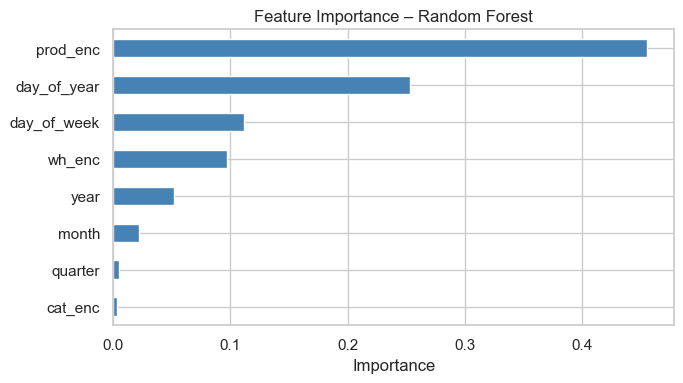

In [8]:
importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance – Random Forest')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('plots/09_feature_importance.png', dpi=150)
plt.show()

## Actual vs Predicted

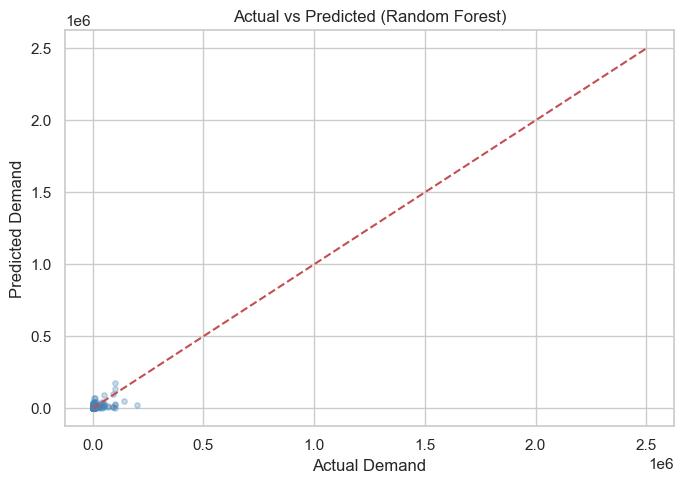

In [9]:
sample = min(500, len(y_test))
idx = np.random.choice(len(y_test), sample, replace=False)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test.iloc[idx], y_pred[idx], alpha=0.3, s=15, color='steelblue')
lim = max(y_test.max(), y_pred.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5)
ax.set_xlabel('Actual Demand')
ax.set_ylabel('Predicted Demand')
ax.set_title('Actual vs Predicted (Random Forest)')
plt.tight_layout()
plt.savefig('plots/10_actual_vs_predicted.png', dpi=150)
plt.show()

## Residuals

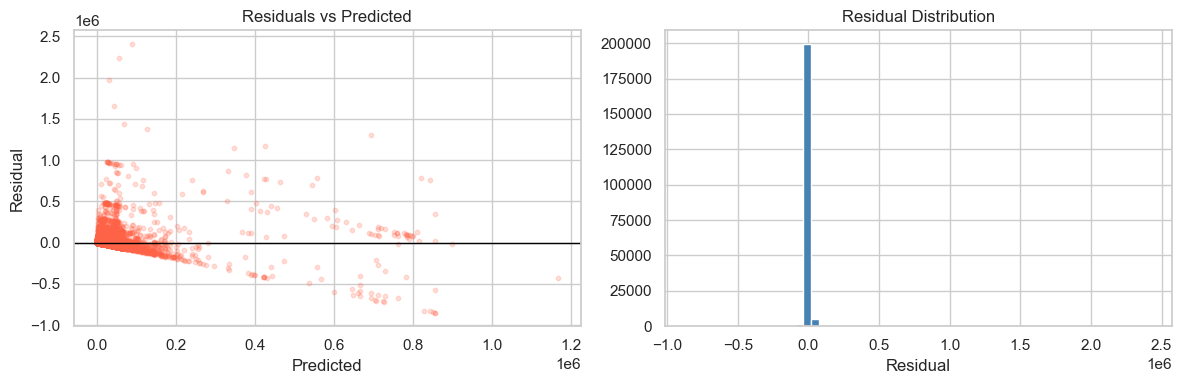

In [10]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.2, s=10, color='tomato')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.savefig('plots/11_residuals.png', dpi=150)
plt.show()

## Save Model

In [11]:
import pickle, os
os.makedirs('ml', exist_ok=True)

with open('ml/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('ml/label_encoders.pkl', 'wb') as f:
    pickle.dump({'warehouse': le_wh, 'category': le_cat, 'product': le_prod}, f)

print("Model saved → ml/rf_model.pkl")
print("Encoders saved → ml/label_encoders.pkl")

Model saved → ml/rf_model.pkl
Encoders saved → ml/label_encoders.pkl
